In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_datareader as pdr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

/Users/joezheng/Desktop/forseeTradeIndex/forseeTradeIndex/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
print("Fetching stock data...")
user_input = input("Enter the stock ticker symbol (e.g., AAPL, MSFT):")
user_date = input("Enter the data range start date (YYYY-MM-DD):")
ticker = user_input.strip().upper()
df = yf.download(ticker, start = user_date)

Fetching stock data...


[*********************100%***********************]  1 of 1 completed


In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-07-22,222.036652,225.823838,221.174113,225.060446,48201800
2024-07-23,223.077591,224.991024,220.767599,222.443088,39960300
2024-07-24,216.663147,222.869395,215.265268,222.076263,61777600
2024-07-25,215.622177,218.953322,212.776815,217.049798,51391200
2024-07-26,216.088165,217.605024,214.154900,216.821800,41601300
...,...,...,...,...,...
2026-07-22,325.890015,329.000000,323.339996,327.869995,38755900
2026-07-23,321.660004,323.299988,319.350006,321.730011,40840800


<Axes: xlabel='Date'>

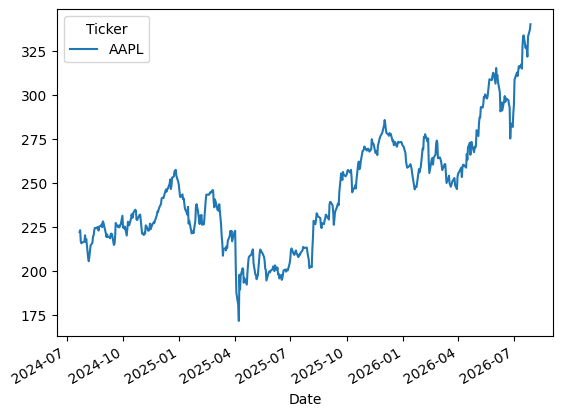

In [5]:
df.Close.plot()

In [6]:
from datetime import datetime, timedelta

num_Days = int(input("Enter the number of days to forecast: "))
df = yf.download(user_input, period=f"{num_Days*2}d", progress=False)
last_n = df.tail(num_Days)
print(last_n)


Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2026-06-15  296.420013  297.779999  291.700012  294.119995   45732600
2026-06-16  299.239990  300.480011  293.970001  295.250000   39874400
2026-06-17  295.950012  302.070007  294.359985  300.850006   42745100
2026-06-18  298.010010  300.570007  295.619995  298.109985   85962200
2026-06-22  297.010010  302.420013  296.760010  297.309998   44879900
2026-06-23  294.299988  301.640015  294.179993  297.540009   52010900
2026-06-24  293.079987  299.700012  292.940002  295.359985   53081900
2026-06-25  275.149994  288.799988  273.750000  287.399994  107013700
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500
2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000
2026-06-30  289.359985  289.940002  280.700012  281.170013   65100200
2026-07-01  294.3800

In [7]:
print(df.head(num_Days))

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-05-01  279.882141  286.955610  278.113751  278.603290  79915400
2026-05-04  276.575165  280.371685  274.606977  279.402577  46668400
2026-05-05  283.918427  284.308082  276.245503  276.675100  49311700
2026-05-06  287.245361  287.764872  280.811287  281.660510  58336100
2026-05-07  287.175415  291.861100  285.516939  289.003717  45224300
2026-05-08  293.050018  294.488695  289.733067  289.743067  52692800
2026-05-11  292.679993  293.880005  290.230011  291.980011  42247300
2026-05-12  294.799988  295.269989  292.559998  292.559998  45748100
2026-05-13  298.869995  300.920013  293.500000  293.500000  52684300
2026-05-14  298.209991  300.450012  295.380005  299.820007  35324900
2026-05-15  300.230011  303.200012  296.519989  297.899994  54862800
2026-05-18  297.839996  300.660004

In [ ]:
df["Target"] = df["Close"].shift(-num_Days)
model_df = df[["Close", "Target"]].dropna()